# Homework 2: Regression
**Name:** Vishnu Gamini  
**GitHub Username:** vishnugamini  
**USC ID:** 6350365744  
**Course:** DSCI 552

In [1]:
from pathlib import Path
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 115, "axes.titlesize": 12})
pd.set_option("display.max_rows", 110)
pd.set_option("display.float_format", lambda x: f"{x:.6g}")
alpha = 0.05

## 1(a). Combined Cycle Power Plant data
Source: [UCI Combined Cycle Power Plant](https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant). The analysis uses **Sheet1**.

In [2]:
data_path = Path("../data/CCPP/Folds5x2_pp.xlsx")
if not data_path.is_file():
    data_path = Path("data/CCPP/Folds5x2_pp.xlsx")
data = pd.read_excel(data_path, sheet_name="Sheet1", engine="openpyxl")
features = ["AT", "V", "AP", "RH"]
target = "PE"
assert data.shape == (9568, 5)
assert data.columns.tolist() == features + [target]
assert not data.isna().any().any()
display(data.head())

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.4,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.5,1009.23,96.62,473.9


## 1(b)(i). Rows and columns
There are **9,568 rows and 5 columns**. Each row is an hourly observation of the plant operating at full load during 2006-2011. Four columns are predictors; the fifth is the response.

| Column | Meaning | Unit |
|---|---|---|
| AT | Ambient temperature (T in the assignment) | degrees Celsius |
| V | Exhaust vacuum | cm Hg |
| AP | Ambient pressure | millibar |
| RH | Relative humidity | percent |
| PE | Net electrical power output (EP in the assignment) | MW |

In [3]:
display(pd.Series({"Rows": len(data), "Columns": data.shape[1],
                   "Missing values": int(data.isna().sum().sum()),
                   "Duplicate rows": int(data.duplicated().sum())}).to_frame("Count"))

,Count
Rows,9568
Columns,5
Missing values,0
Duplicate rows,41


## 1(b)(ii). Pairwise scatterplots

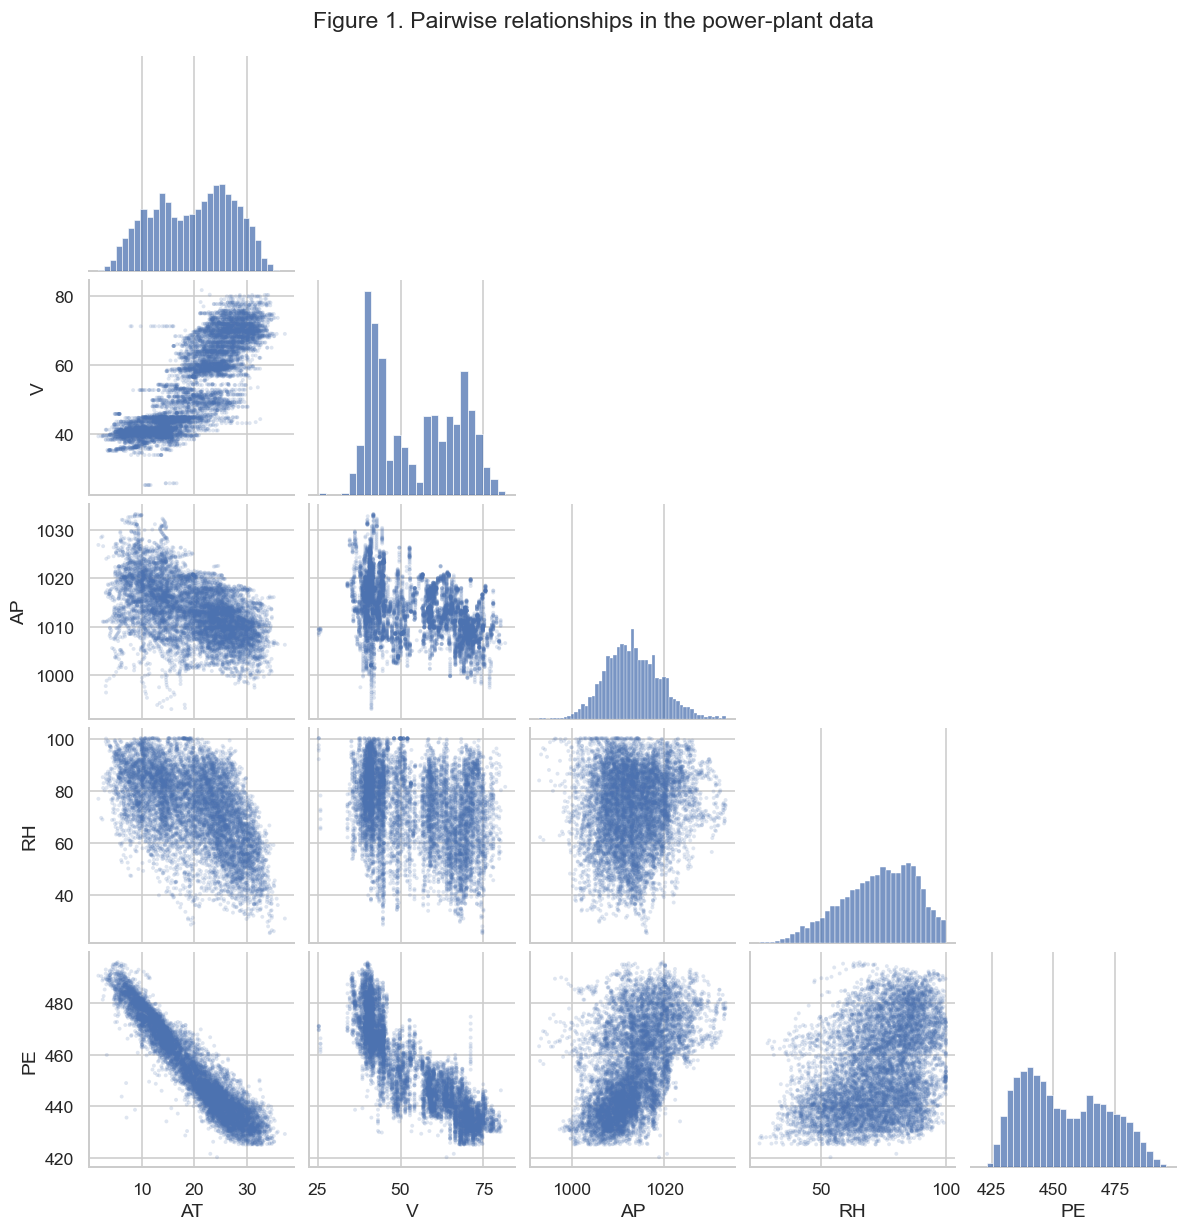

,AT,V,AP,RH,PE
AT,1,0.844,-0.508,-0.543,-0.948
V,0.844,1,-0.414,-0.312,-0.87
AP,-0.508,-0.414,1,0.1,0.518
RH,-0.543,-0.312,0.1,1,0.39
PE,-0.948,-0.87,0.518,0.39,1


In [4]:
g = sns.pairplot(data, corner=True, diag_kind="hist", height=2.1,
                 plot_kws={"s": 6, "alpha": 0.18, "edgecolor": "none"})
g.figure.suptitle("Figure 1. Pairwise relationships in the power-plant data", y=1.02)
plt.show()
display(data.corr().round(3))

PE decreases strongly as AT increases and also decreases with V. PE has weaker positive associations with AP and RH. AT and V are strongly positively related, while AT and RH are negatively related. Curvature and changing spread are visible, particularly for PE versus AT and V. Correlated predictors explain why a simple-regression slope can differ from its multiple-regression slope.

## 1(b)(iii). Descriptive statistics
The range is the maximum minus the minimum; the interquartile range is Q3 minus Q1.

In [5]:
summary = pd.DataFrame({"Mean": data.mean(), "Median": data.median(),
                        "Range": data.max() - data.min(), "Q1": data.quantile(0.25),
                        "Q3": data.quantile(0.75),
                        "IQR": data.quantile(0.75) - data.quantile(0.25)})
display(summary)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.6512,20.345,35.3,13.51,25.72,12.21
V,54.3058,52.08,56.2,41.74,66.54,24.8
AP,1013.26,1012.94,40.41,1009.1,1017.26,8.16
RH,73.309,74.975,74.6,63.3275,84.83,21.5025
PE,454.365,451.55,75.5,439.75,468.43,28.68


## 1(c). Simple linear regression
Each model has the form PE = intercept + slope × predictor. Two-sided slope tests use a 5% significance level. Potential response outliers are flagged by an absolute internally studentized residual greater than 3; Cook's distance greater than 4/n flags potentially influential observations.

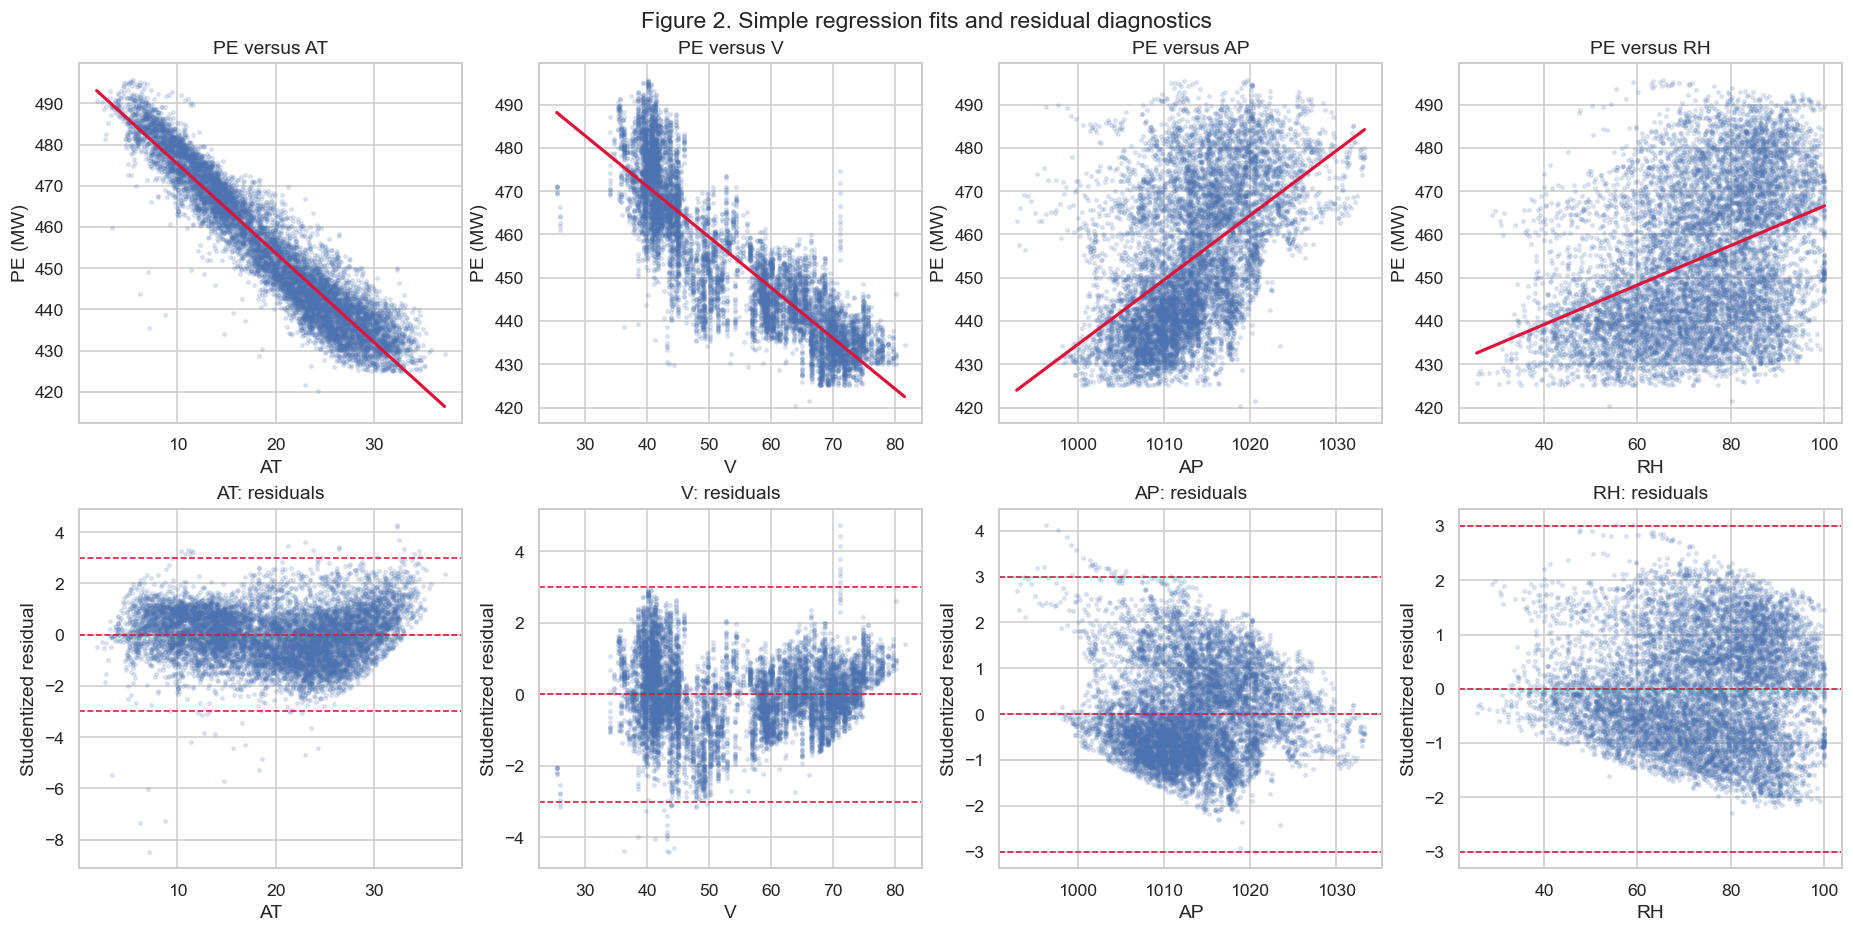

,Intercept,Slope,SE,p-value,CI low,CI high,R squared
Predictor,,,,,,,
AT,497.034,-2.17132,0.00744329,0,-2.18591,-2.15673,0.898948
V,517.802,-1.16814,0.00677567,0,-1.18142,-1.15485,0.756518
AP,-1055.26,1.48987,0.0251259,0,1.44062,1.53912,0.268769
RH,420.962,0.45565,0.0110064,0,0.434075,0.477225,0.151939


,Abs. residual > 3,Cook D > 4/n,Largest residual row,Largest abs. residual
Predictor,,,,
AT,42,416,7665,8.47086
V,33,423,3104,4.74537
AP,29,300,1291,4.13021
RH,2,249,7901,3.02224


In [6]:
simple_models, simple_rows, outlier_rows = {}, [], []
fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
for j, feature in enumerate(features):
    model = smf.ols(f"PE ~ {feature}", data=data).fit()
    simple_models[feature] = model
    low, high = model.conf_int().loc[feature]
    simple_rows.append({"Predictor": feature, "Intercept": model.params["Intercept"],
                        "Slope": model.params[feature], "SE": model.bse[feature],
                        "p-value": model.pvalues[feature], "CI low": low, "CI high": high,
                        "R squared": model.rsquared})
    influence = model.get_influence()
    residuals = influence.resid_studentized_internal
    cooks = influence.cooks_distance[0]
    outlier_rows.append({"Predictor": feature, "Abs. residual > 3": int((abs(residuals) > 3).sum()),
                         "Cook D > 4/n": int((cooks > 4 / len(data)).sum()),
                         "Largest residual row": int(np.argmax(abs(residuals)) + 1),
                         "Largest abs. residual": abs(residuals).max()})
    grid = pd.DataFrame({feature: np.linspace(data[feature].min(), data[feature].max(), 250)})
    axes[0, j].scatter(data[feature], data.PE, s=5, alpha=0.15)
    axes[0, j].plot(grid[feature], model.predict(grid), color="crimson", linewidth=2)
    axes[0, j].set(xlabel=feature, ylabel="PE (MW)", title=f"PE versus {feature}")
    axes[1, j].scatter(data[feature], residuals, s=5, alpha=0.15)
    for level in [-3, 0, 3]: axes[1, j].axhline(level, color="crimson", linestyle="--", linewidth=1)
    axes[1, j].set(xlabel=feature, ylabel="Studentized residual", title=f"{feature}: residuals")
fig.suptitle("Figure 2. Simple regression fits and residual diagnostics")
plt.show()
simple_summary = pd.DataFrame(simple_rows).set_index("Predictor")
outlier_summary = pd.DataFrame(outlier_rows).set_index("Predictor")
display(simple_summary)
display(outlier_summary)

All four slopes are statistically significant at 5%. AT has the strongest simple fit (R² = 0.8989). The slopes for AT and V are negative; those for AP and RH are positive. Each slope is the estimated change in MW for a one-unit increase in its predictor. Displayed p-values of zero reflect numerical underflow, not an exactly zero probability.

The diagnostic table identifies observations worth investigating in each model. The one-based row numbers refer to data rows, excluding the Excel header. Large residuals alone do not establish a recording error: a one-predictor model also omits other relevant conditions. No observations are removed solely because of these flags.

## 1(d). Multiple linear regression
All four predictors enter the same model. The coefficient tests evaluate H0: beta_j = 0 while holding the other predictors fixed.

In [7]:
multiple = smf.ols("PE ~ AT + V + AP + RH", data=data).fit()
def coefficient_table(model):
    ci = model.conf_int()
    return pd.DataFrame({"Coefficient": model.params, "SE": model.bse,
                         "t": model.tvalues, "p-value": model.pvalues,
                         "CI low": ci[0], "CI high": ci[1]})
display(coefficient_table(multiple))
display(pd.Series({"R squared": multiple.rsquared,
                   "Adjusted R squared": multiple.rsquared_adj}).to_frame("Value"))

,Coefficient,SE,t,p-value,CI low,CI high
Intercept,454.609,9.74851,46.6337,0,435.5,473.718
AT,-1.97751,0.015289,-129.342,0,-2.00748,-1.94754
V,-0.233916,0.0072821,-32.1221,4.37531e-215,-0.248191,-0.219642
AP,0.0620829,0.00945797,6.56409,5.50711e-11,0.0435433,0.0806226
RH,-0.158054,0.00416826,-37.9185,3.10458e-293,-0.166225,-0.149883


,Value
R squared,0.928696
Adjusted R squared,0.928666


All four predictor p-values are below 0.05, so H0 is rejected for AT, V, AP, and RH. The model explains 92.87% of the variation in PE. AT and V retain negative coefficients; AP remains positive. RH becomes negative after adjustment for the other predictors. These are conditional associations, rather than evidence of causation.

## 1(e). Simple versus multiple regression coefficients

,Simple slope,Multiple slope
AT,-2.17132,-1.97751
V,-1.16814,-0.233916
AP,1.48987,0.0620829
RH,0.45565,-0.158054


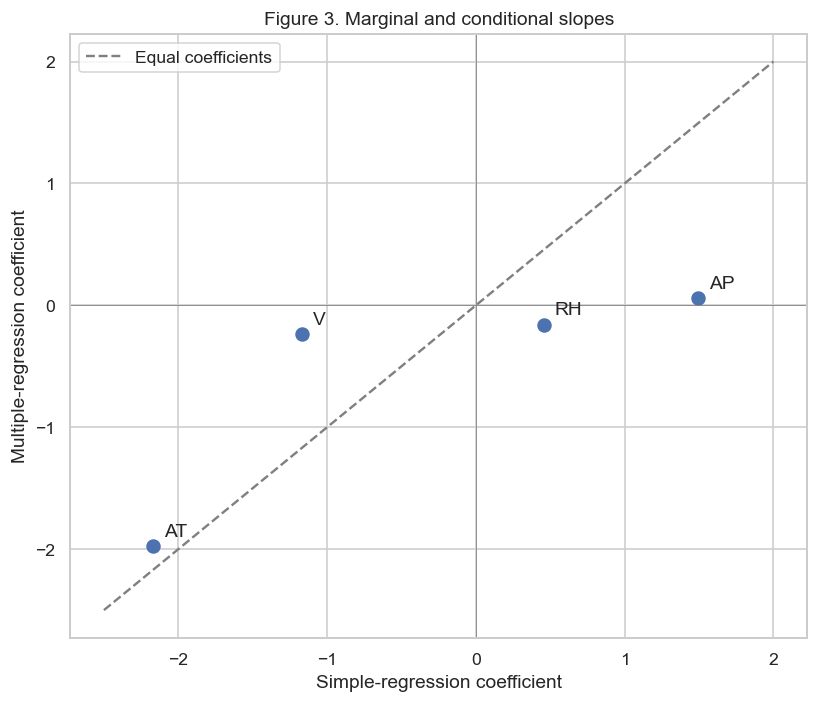

In [8]:
coefficient_comparison = pd.DataFrame({"Simple slope": simple_summary.Slope,
                                       "Multiple slope": multiple.params[features]})
display(coefficient_comparison)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
ax.scatter(coefficient_comparison["Simple slope"], coefficient_comparison["Multiple slope"], s=65)
for feature, row in coefficient_comparison.iterrows():
    ax.annotate(feature, (row["Simple slope"], row["Multiple slope"]), xytext=(7, 6), textcoords="offset points")
limits = [-2.5, 2.0]
ax.plot(limits, limits, "--", color="gray", label="Equal coefficients")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set(xlabel="Simple-regression coefficient", ylabel="Multiple-regression coefficient",
       title="Figure 3. Marginal and conditional slopes")
ax.legend()
plt.show()

AT changes relatively little, while the magnitudes of the V and AP slopes shrink substantially. RH reverses sign. A simple slope includes associations shared with the omitted predictors, whereas a multiple-regression slope adjusts for them. For example, higher RH is associated with lower AT, and lower AT is associated with higher PE. This helps explain the positive simple RH slope.

## 1(f). Nonlinear associations
For each predictor X, fit PE = beta_0 + beta_1 X + beta_2 X² + beta_3 X³.
The nested F-test compares the cubic model with its simple linear model and tests H0: beta_2 = beta_3 = 0 jointly. Individual coefficient p-values are also reported.

AT


,Coefficient,SE,t,p-value,CI low,CI high
Intercept,492.728,0.672898,732.248,0,491.409,494.047
AT,-0.610346,0.123523,-4.94115,7.89815e-07,-0.852477,-0.368214
I(AT ** 2),-0.125138,0.00687614,-18.1989,8.83305e-73,-0.138617,-0.111659
I(AT ** 3),0.00267485,0.000118387,22.5942,3.65218e-110,0.00244279,0.00290692


V


,Coefficient,SE,t,p-value,CI low,CI high
Intercept,554.147,9.15078,60.5574,0,536.209,572.084
V,-2.14438,0.508812,-4.21448,2.52659e-05,-3.14176,-1.147
I(V ** 2),-0.00271228,0.00921449,-0.29435,0.768497,-0.0207746,0.0153501
I(V ** 3),0.000134357,5.45152e-05,2.46458,0.0137349,2.74957e-05,0.000241219


AP


,Coefficient,SE,t,p-value,CI low,CI high
Intercept,0.0746936,0.00887652,8.41474,4.50273e-17,0.0572937,0.0920934
AP,25.2556,3.00135,8.41474,4.50274e-17,19.3723,31.1389
I(AP ** 2),-0.0499521,0.00591922,-8.43896,3.6667e-17,-0.061555,-0.0383491
I(AP ** 3),2.51353e-05,2.91839e-06,8.61272,8.26415e-18,1.94146e-05,3.08559e-05


RH


,Coefficient,SE,t,p-value,CI low,CI high
Intercept,468.414,10.5447,44.4216,0,447.744,489.083
RH,-1.72921,0.486174,-3.55678,0.000377251,-2.68222,-0.776207
I(RH ** 2),0.0321452,0.00725129,4.43303,9.39543e-06,0.0179311,0.0463592
I(RH ** 3),-0.000152188,3.50673e-05,-4.33988,1.44028e-05,-0.000220927,-8.34485e-05


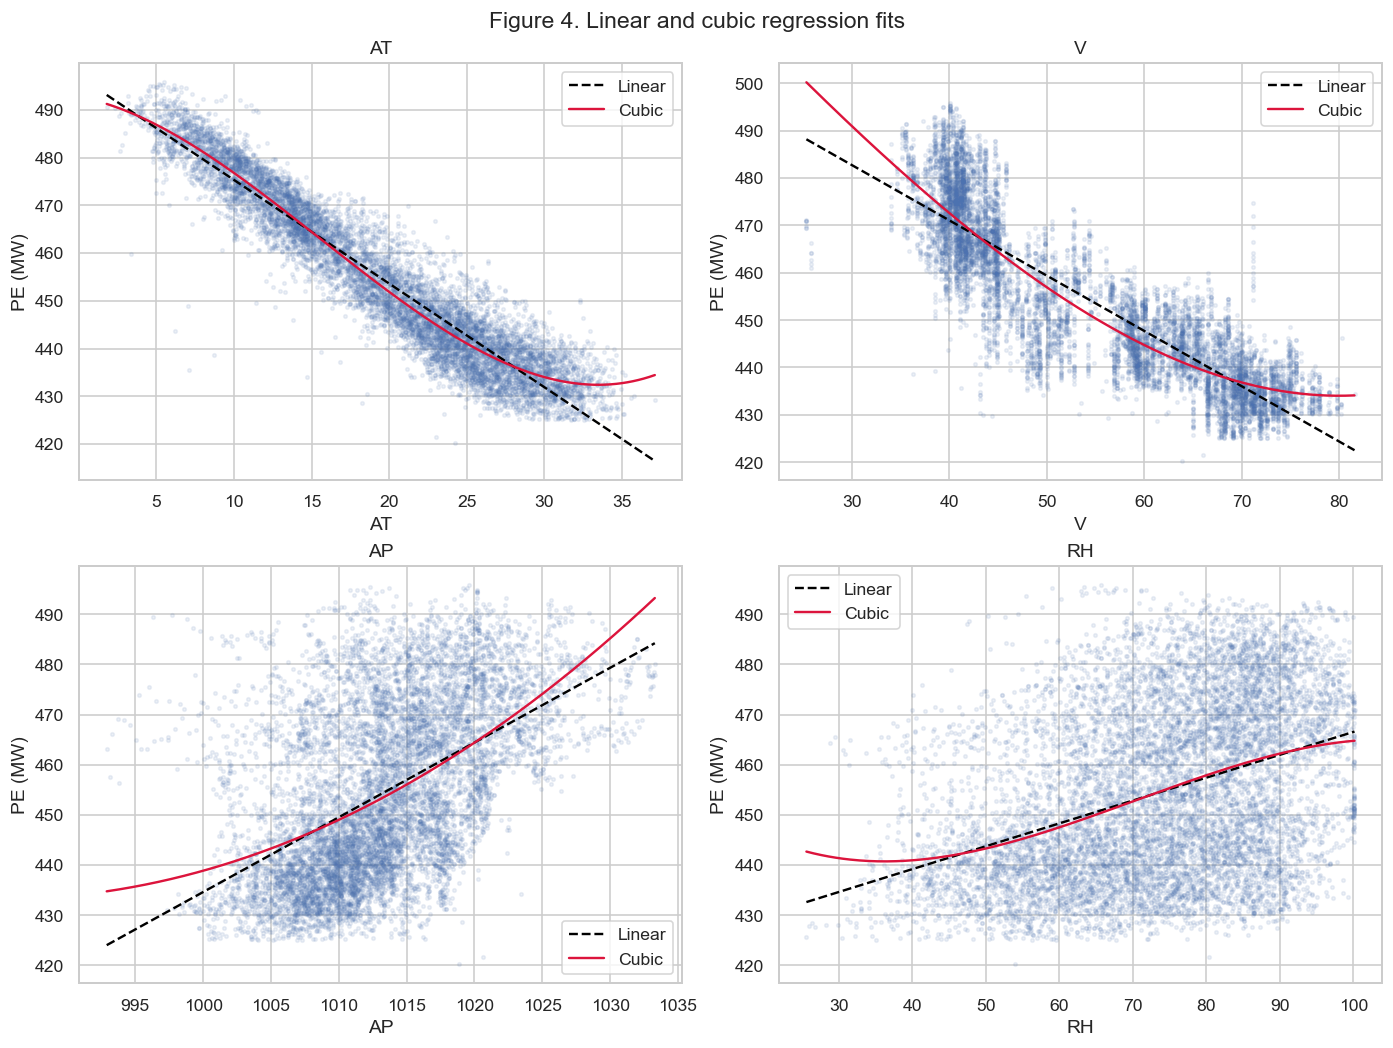

,R squared,Nonlinearity F,Joint p-value
Predictor,,,
AT,0.911883,701.967,3.47838e-285
V,0.775022,393.314,7.0403e-165
AP,0.274863,80.3922,3.64681e-19
RH,0.153743,10.1889,3.79962e-05


In [9]:
cubic_models, cubic_rows = {}, []
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, feature in zip(axes.flat, features):
    model = smf.ols(f"PE ~ {feature} + I({feature}**2) + I({feature}**3)", data=data).fit()
    cubic_models[feature] = model
    f_stat, p_value, df_difference = model.compare_f_test(simple_models[feature])
    cubic_rows.append({"Predictor": feature, "R squared": model.rsquared,
                       "Nonlinearity F": f_stat, "Joint p-value": p_value})
    print(feature)
    display(coefficient_table(model))
    grid = pd.DataFrame({feature: np.linspace(data[feature].min(), data[feature].max(), 300)})
    ax.scatter(data[feature], data.PE, s=5, alpha=0.1)
    ax.plot(grid[feature], simple_models[feature].predict(grid), label="Linear", color="black", linestyle="--")
    ax.plot(grid[feature], model.predict(grid), label="Cubic", color="crimson")
    ax.set(xlabel=feature, ylabel="PE (MW)", title=feature)
    ax.legend()
fig.suptitle("Figure 4. Linear and cubic regression fits")
plt.show()
cubic_summary = pd.DataFrame(cubic_rows).set_index("Predictor")
display(cubic_summary)

The joint tests find evidence of nonlinearity for **AT, V, AP, RH** at the 5% level. The joint test is the relevant comparison with a straight line; a significant first-order coefficient alone would not demonstrate nonlinearity. The cubic models remain linear in their coefficients even though they are nonlinear in X.

## 1(g). Pairwise interactions
The model includes four main effects and all six distinct pairwise interactions. An interaction means that the slope for one predictor depends on the value of another.

In [10]:
interaction_model = smf.ols("PE ~ (AT + V + AP + RH)**2", data=data).fit()
interaction_coefficients = coefficient_table(interaction_model)
display(interaction_coefficients)
interaction_terms = [term for term in interaction_model.params.index if ":" in term]
significant_interactions = [term for term in interaction_terms if interaction_model.pvalues[term] < alpha]
f_interaction, p_interaction, _ = interaction_model.compare_f_test(multiple)
display(pd.Series({"Joint interaction F": f_interaction, "Joint p-value": p_interaction,
                   "R squared": interaction_model.rsquared}).to_frame("Value"))

,Coefficient,SE,t,p-value,CI low,CI high
Intercept,685.782,78.6401,8.72052,3.23161e-18,531.631,839.934
AT,-4.34701,2.37314,-1.83176,0.0670187,-8.99887,0.304842
V,-7.67486,1.35076,-5.68188,1.37125e-08,-10.3226,-5.02708
AP,-0.152355,0.076817,-1.98335,0.0473573,-0.302932,-0.0017771
RH,1.57091,0.77335,2.0313,0.0422521,0.0549762,3.08684
AT:V,0.0209709,0.000898583,23.3378,3.33336e-117,0.0192095,0.0227323
AT:AP,0.00175905,0.00233906,0.752031,0.452051,-0.00282601,0.0063441
AT:RH,-0.00523035,0.000811618,-6.44436,1.21694e-10,-0.0068213,-0.00363941
V:AP,0.00681235,0.00132665,5.135,2.87703e-07,0.00421184,0.00941287
V:RH,0.000838633,0.000488713,1.716,0.0861937,-0.000119348,0.00179661


,Value
Joint interaction F,190.299
Joint p-value,8.06436e-230
R squared,0.936306


The statistically significant interaction terms are **AT:V, AT:RH, V:AP, AP:RH** at the 5% level. The joint interaction test also rejects the no-interaction model (p = 8.06e-230). These are nominal, unadjusted coefficient tests; the joint test evaluates the interaction terms together.

## 1(h). Prediction with linear and quadratic-interaction models
A fixed random split assigns 70% of rows to training and 30% to testing (`random_state=42`). The expanded model contains all four main effects, four squares, and six pairwise interactions. Predictors are centered using training means before constructing the expanded model.

Backward elimination removes the eligible term with the largest p-value above 0.05 and refits the model. Strong hierarchy is preserved: a main effect cannot be removed while its square or an interaction containing it remains. Selection uses training data only.

In [11]:
train, test = train_test_split(data, test_size=0.30, random_state=42, shuffle=True)
assert len(train) == 6697 and len(test) == 2871
assert set(train.index).isdisjoint(test.index)
y_train, y_test = train.PE, test.PE
linear_train = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()
centers = train[features].mean()
def quadratic_design(frame):
    centered = frame[features] - centers
    design = centered.copy()
    for feature in features: design[f"{feature}^2"] = centered[feature] ** 2
    for a, b in combinations(features, 2): design[f"{a}:{b}"] = centered[a] * centered[b]
    return sm.add_constant(design, has_constant="add")

Q_train, Q_test = quadratic_design(train), quadratic_design(test)
terms = Q_train.columns.tolist()
quadratic_full = sm.OLS(y_train, Q_train).fit()
removal_history = []
while True:
    fitted = sm.OLS(y_train, Q_train[terms]).fit()
    eligible = []
    for term in terms:
        if term == "const": continue
        if term in features:
            has_square = f"{term}^2" in terms
            has_interaction = any(":" in other and term in other.split(":") for other in terms)
            if has_square or has_interaction: continue
        eligible.append(term)
    if not eligible: break
    worst = fitted.pvalues[eligible].idxmax()
    if fitted.pvalues[worst] <= alpha: break
    removal_history.append({"Removed term": worst, "p-value at removal": fitted.pvalues[worst]})
    terms.remove(worst)
quadratic_selected = fitted
display(pd.DataFrame(removal_history))
display(coefficient_table(quadratic_selected))

regression_rows = []
for name, model, train_input, test_input in [
    ("Linear (all predictors)", linear_train, train, test),
    ("Full quadratic + interactions", quadratic_full, Q_train, Q_test),
    ("Selected quadratic + interactions", quadratic_selected, Q_train[terms], Q_test[terms])]:
    regression_rows.append({"Model": name, "Train MSE": mean_squared_error(y_train, model.predict(train_input)),
                            "Test MSE": mean_squared_error(y_test, model.predict(test_input))})
regression_scores = pd.DataFrame(regression_rows).set_index("Model")
display(regression_scores)

,Removed term,p-value at removal
0,V:RH,0.867382
1,V^2,0.607733
2,V:AP,0.357826


,Coefficient,SE,t,p-value,CI low,CI high
const,453.228,0.0989146,4582.01,0,453.034,453.421
AT,-1.81727,0.0194818,-93.2802,0,-1.85546,-1.77908
V,-0.298531,0.00888661,-33.5934,9.36883e-229,-0.315952,-0.28111
AP,0.116926,0.011569,10.1068,7.64032e-24,0.0942467,0.139605
RH,-0.125096,0.00511141,-24.4738,9.28731e-127,-0.135115,-0.115076
AT^2,0.0195345,0.00240795,8.11248,5.8538e-16,0.0148141,0.0242548
AP^2,-0.00764403,0.00133498,-5.72595,1.0732e-08,-0.010261,-0.00502704
RH^2,-0.00194027,0.000275363,-7.04622,2.02248e-12,-0.00248007,-0.00140047
AT:V,0.00824627,0.00145612,5.66317,1.54774e-08,0.0053918,0.0111007
AT:AP,0.00697514,0.00219724,3.1745,0.00150777,0.00266784,0.0112824


,Train MSE,Test MSE
Model,,
Linear (all predictors),20.5808,21.2399
Full quadratic + interactions,17.8878,18.6473
Selected quadratic + interactions,17.8908,18.66


The all-predictor linear model has test MSE **21.2399 MW²**. After hierarchical elimination, the expanded model has test MSE **18.6600 MW²**, a reduction of **12.15%**. The removal table records each decision at its current fitted p-value. A retained main effect may have p > 0.05 because it supports a retained higher-order term. P-values after selection describe the fitted model and should not be interpreted as independent confirmatory tests.

## 1(i). KNN regression with raw and normalized features
Both versions use Euclidean distance, uniform neighbor weights, the same 70/30 split, and k = 1 through 100. Normalization is min-max scaling fitted on the training predictors only. The reported best k minimizes the displayed test MSE; therefore this test set is also used for tuning rather than providing an untouched final evaluation. Training MSE includes each training observation among its own neighbors.

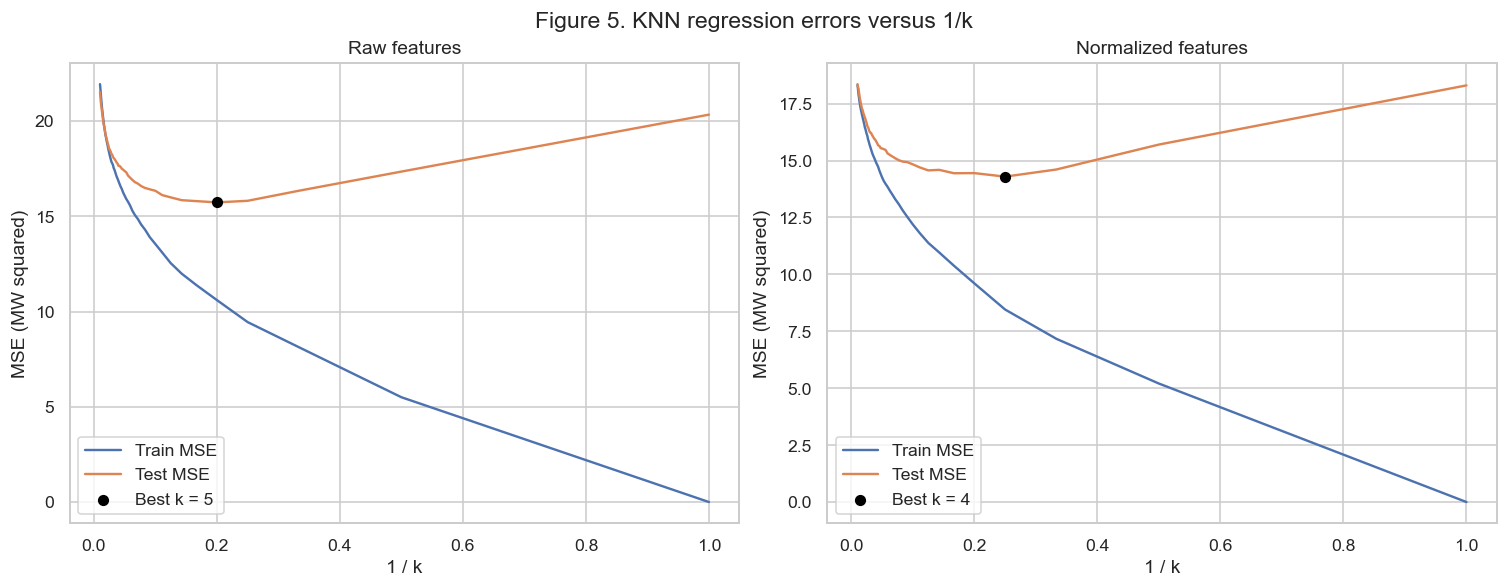

,k,Train MSE,Test MSE
Raw,5,10.6008,15.7268
Normalized,4,8.45435,14.2913


In [12]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(train[features])
X_test_scaled = scaler.transform(test[features])
knn_results = {}
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (name, Xtr, Xte) in zip(axes, [
    ("Raw", train[features].to_numpy(), test[features].to_numpy()),
    ("Normalized", X_train_scaled, X_test_scaled)]):
    rows = []
    for k in range(1, 101):
        model = KNeighborsRegressor(n_neighbors=k, weights="uniform", metric="euclidean", algorithm="kd_tree")
        model.fit(Xtr, y_train)
        rows.append({"k": k, "Train MSE": mean_squared_error(y_train, model.predict(Xtr)),
                     "Test MSE": mean_squared_error(y_test, model.predict(Xte))})
    table = pd.DataFrame(rows)
    knn_results[name] = table
    best = table.sort_values(["Test MSE", "k"]).iloc[0]
    ax.plot(1 / table.k, table["Train MSE"], label="Train MSE")
    ax.plot(1 / table.k, table["Test MSE"], label="Test MSE")
    ax.scatter([1 / best.k], [best["Test MSE"]], color="black", zorder=5,
               label=f"Best k = {int(best.k)}")
    ax.set(xlabel="1 / k", ylabel="MSE (MW squared)", title=f"{name} features")
    ax.legend()
fig.suptitle("Figure 5. KNN regression errors versus 1/k")
plt.show()
knn_best = pd.DataFrame({name: table.sort_values(["Test MSE", "k"]).iloc[0]
                         for name, table in knn_results.items()}).T
knn_best["k"] = knn_best["k"].astype(int)
display(knn_best)

Raw features give **k = 5**, test MSE **15.7268 MW²**. Normalized features give **k = 4**, test MSE **14.2913 MW²**. Small k produces a more flexible fit, while larger k smooths predictions over a wider neighborhood. Scaling changes which observations are nearest neighbors because the four predictors use different units.

## 1(j). KNN versus the best regression model
Only the regression models fitted on the 70% training set are compared with KNN. Models fitted on all observations in parts (c)-(g) are excluded from this test comparison.

In [13]:
best_regression_name = regression_scores["Test MSE"].idxmin()
comparison = pd.concat([
    regression_scores.loc[[best_regression_name]],
    knn_best[["Train MSE", "Test MSE"]].rename(index={"Raw": "KNN raw", "Normalized": "KNN normalized"})])
comparison["Test RMSE (MW)"] = np.sqrt(comparison["Test MSE"])
display(comparison.sort_values("Test MSE"))

,Train MSE,Test MSE,Test RMSE (MW)
KNN normalized,8.45435,14.2913,3.78039
KNN raw,10.6008,15.7268,3.96571
Full quadratic + interactions,17.8878,18.6473,4.31825


**KNN normalized** has the smallest test MSE, **14.2913 MW²** (RMSE **3.7804 MW**). KNN can capture local nonlinear behavior without specifying a polynomial formula, whereas regression offers an explicit equation and coefficient interpretation. The 41 repeated rows in Sheet1 are retained as supplied; random splitting can put identical observations in both sets. Together with test-based k selection, this limits how strongly the observed errors can be generalized to new operating conditions.

## 2. ISLR 2.4.1
**(a)** A flexible method would generally perform better when n is very large and p is small. The abundant observations help control estimation variance while allowing a flexible model to capture structure that a restrictive model could miss.

**(b)** A flexible method would generally perform worse when p is very large and n is small. Too many possible patterns relative to the available observations increase overfitting and prediction variance.

**(c)** A flexible method would generally perform better for a highly nonlinear relationship, because it can represent curvature that an inflexible method may miss.

**(d)** A flexible method would generally perform worse when the error variance is extremely high. It can fit random noise, increasing variance without reducing the irreducible error.

## 3. ISLR 2.4.7
### (a) Distances from (0, 0, 0)
The Euclidean distance is the square root of X1² + X2² + X3².

In [14]:
example = pd.DataFrame({"X1": [0, 2, 0, 0, -1, 1], "X2": [3, 0, 1, 1, 0, 1],
                        "X3": [0, 0, 3, 2, 1, 1],
                        "Class": ["Red", "Red", "Red", "Green", "Green", "Red"]},
                       index=pd.Index(range(1, 7), name="Observation"))
example["Distance"] = np.linalg.norm(example[["X1", "X2", "X3"]], axis=1)
display(example)

,X1,X2,X3,Class,Distance
Observation,,,,,
1,0,3,0,Red,3
2,2,0,0,Red,2
3,0,1,3,Red,3.16228
4,0,1,2,Green,2.23607
5,-1,0,1,Green,1.41421
6,1,1,1,Red,1.73205


The exact distances for observations 1 through 6 are **3, 2, sqrt(10), sqrt(5), sqrt(2), and sqrt(3)**.

### (b) K = 1
**Green.** Observation 5 is the closest point, at distance sqrt(2), and its class is Green.

### (c) K = 3
**Red.** The three closest observations are 5 (Green), 6 (Red), and 2 (Red), giving two Red votes and one Green vote.

### (d) Nonlinear Bayes boundary
A **small K** is preferable for a highly nonlinear boundary because it allows a flexible, local decision boundary. A large K averages over wider regions and can smooth away the curvature. The best K still balances this flexibility against sampling noise.

## References
1. Tüfekci, P., and Kaya, H. (2014). *Combined Cycle Power Plant*. UCI Machine Learning Repository. [Dataset](https://doi.org/10.24432/C5002N), CC BY 4.0. Sheet1 of `Folds5x2_pp.xlsx`.
2. James, G., Witten, D., Hastie, T., and Tibshirani, R. *An Introduction to Statistical Learning*, first edition, seventh printing. Section 2.4, exercises 1 and 7, pp. 52-54. [Author-provided textbook](https://www.statlearning.com/s/ISLRSeventhPrinting.pdf).
3. statsmodels: [OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html), [nested F-tests](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.compare_f_test.html), and [influence diagnostics](https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html).
4. scikit-learn: [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) and [MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html).